In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-02 11:02:44.658518


# Fine-tuned filtering

* Transcript count: just remove cells in top quarter of percent for each sample
* Area: No threshold
* Doublet scores: remove cells scored > 99th percentile using scrublet

In [2]:
import os
from pathlib import Path
import scanpy as sc
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import anndata as ad
import session_info

In [3]:
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = base_dir / "data/h5ad/export_01/01c_scrublet"
output_dir = base_dir / "data/h5ad/export_01/01d_filter"

output_dir.mkdir(parents = True, exist_ok = True)

In [5]:
sample_files = [os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith('.h5ad')]
adata_list = [sc.read_h5ad(f) for f in sample_files]

adata_list = sorted(adata_list, key=lambda ad: ad.obs["sample_id"].iloc[0])

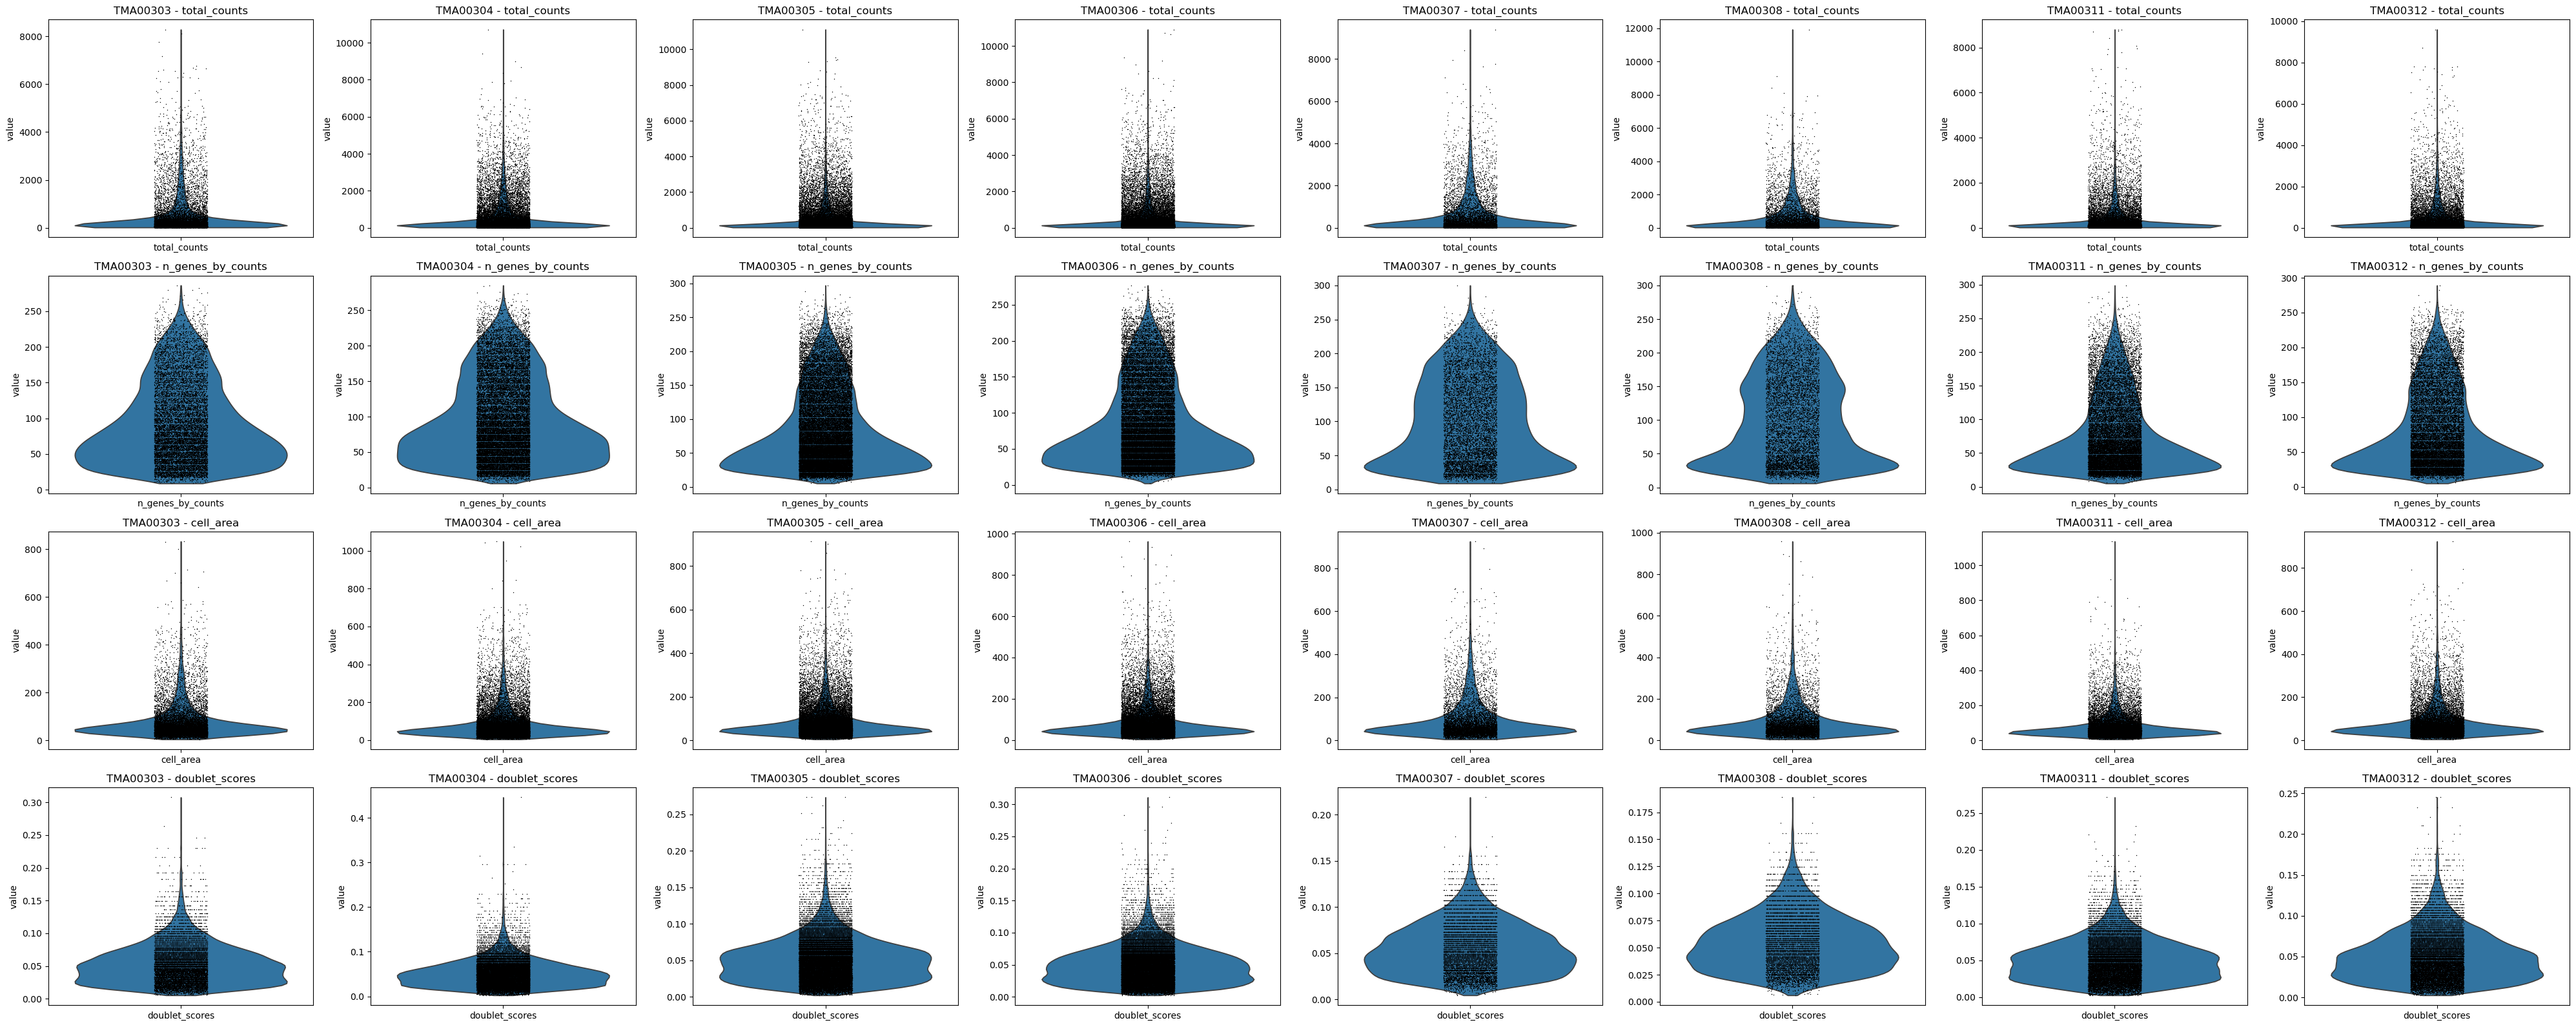

In [6]:
features = ['total_counts', 'n_genes_by_counts', 'cell_area', 'doublet_scores']

# Create subplots
fig, axes = plt.subplots(len(features), len(adata_list), figsize=(len(adata_list) * 5, len(features) * 4))
for col_idx, adata in enumerate(adata_list):
    for row_idx, feature in enumerate(features):
        sc.pl.violin(adata, feature, ax=axes[row_idx, col_idx], show=False)
        axes[row_idx, col_idx].set_title(f"{adata.obs['sample_id'].unique()[0]} - {feature}")

plt.tight_layout()
plt.show()

## Filters

In [7]:
# Doublet scores -- remove cells scoring in top 1% for doublets
for i, adata in enumerate(adata_list):
    print(f"Dataset {i} shape before doublet_scores ceiling threshold: {adata.shape}")
    doublet_scores_ceiling = adata.obs['doublet_scores'].quantile(0.99)
    adata_list[i] = adata[adata.obs['doublet_scores'] < doublet_scores_ceiling, :]
    print(f"Dataset {i} shape after doublet_scores ceiling threshold: {adata_list[i].shape}")

Dataset 0 shape before doublet_scores ceiling threshold: (11408, 480)
Dataset 0 shape after doublet_scores ceiling threshold: (11290, 480)
Dataset 1 shape before doublet_scores ceiling threshold: (21501, 480)
Dataset 1 shape after doublet_scores ceiling threshold: (21238, 480)
Dataset 2 shape before doublet_scores ceiling threshold: (33118, 480)
Dataset 2 shape after doublet_scores ceiling threshold: (32764, 480)
Dataset 3 shape before doublet_scores ceiling threshold: (32284, 480)
Dataset 3 shape after doublet_scores ceiling threshold: (31934, 480)
Dataset 4 shape before doublet_scores ceiling threshold: (7006, 480)
Dataset 4 shape after doublet_scores ceiling threshold: (6929, 480)
Dataset 5 shape before doublet_scores ceiling threshold: (6951, 480)
Dataset 5 shape after doublet_scores ceiling threshold: (6873, 480)
Dataset 6 shape before doublet_scores ceiling threshold: (19767, 480)
Dataset 6 shape after doublet_scores ceiling threshold: (19538, 480)
Dataset 7 shape before doublet_

In [8]:
# Doublet scores -- remove cells scoring in top 1% for doublets
for i, adata in enumerate(adata_list):
    print(f"Dataset {i} shape before doublet_scores ceiling threshold: {adata.shape}")
    doublet_scores_ceiling = adata.obs['doublet_scores'].quantile(0.99)
    adata_list[i] = adata[adata.obs['doublet_scores'] < doublet_scores_ceiling, :]
    print(f"Dataset {i} shape after doublet_scores ceiling threshold: {adata_list[i].shape}")

Dataset 0 shape before doublet_scores ceiling threshold: (11290, 480)
Dataset 0 shape after doublet_scores ceiling threshold: (11122, 480)
Dataset 1 shape before doublet_scores ceiling threshold: (21238, 480)
Dataset 1 shape after doublet_scores ceiling threshold: (21020, 480)
Dataset 2 shape before doublet_scores ceiling threshold: (32764, 480)
Dataset 2 shape after doublet_scores ceiling threshold: (32361, 480)
Dataset 3 shape before doublet_scores ceiling threshold: (31934, 480)
Dataset 3 shape after doublet_scores ceiling threshold: (31535, 480)
Dataset 4 shape before doublet_scores ceiling threshold: (6929, 480)
Dataset 4 shape after doublet_scores ceiling threshold: (6835, 480)
Dataset 5 shape before doublet_scores ceiling threshold: (6873, 480)
Dataset 5 shape after doublet_scores ceiling threshold: (6765, 480)
Dataset 6 shape before doublet_scores ceiling threshold: (19538, 480)
Dataset 6 shape after doublet_scores ceiling threshold: (19336, 480)
Dataset 7 shape before doublet_

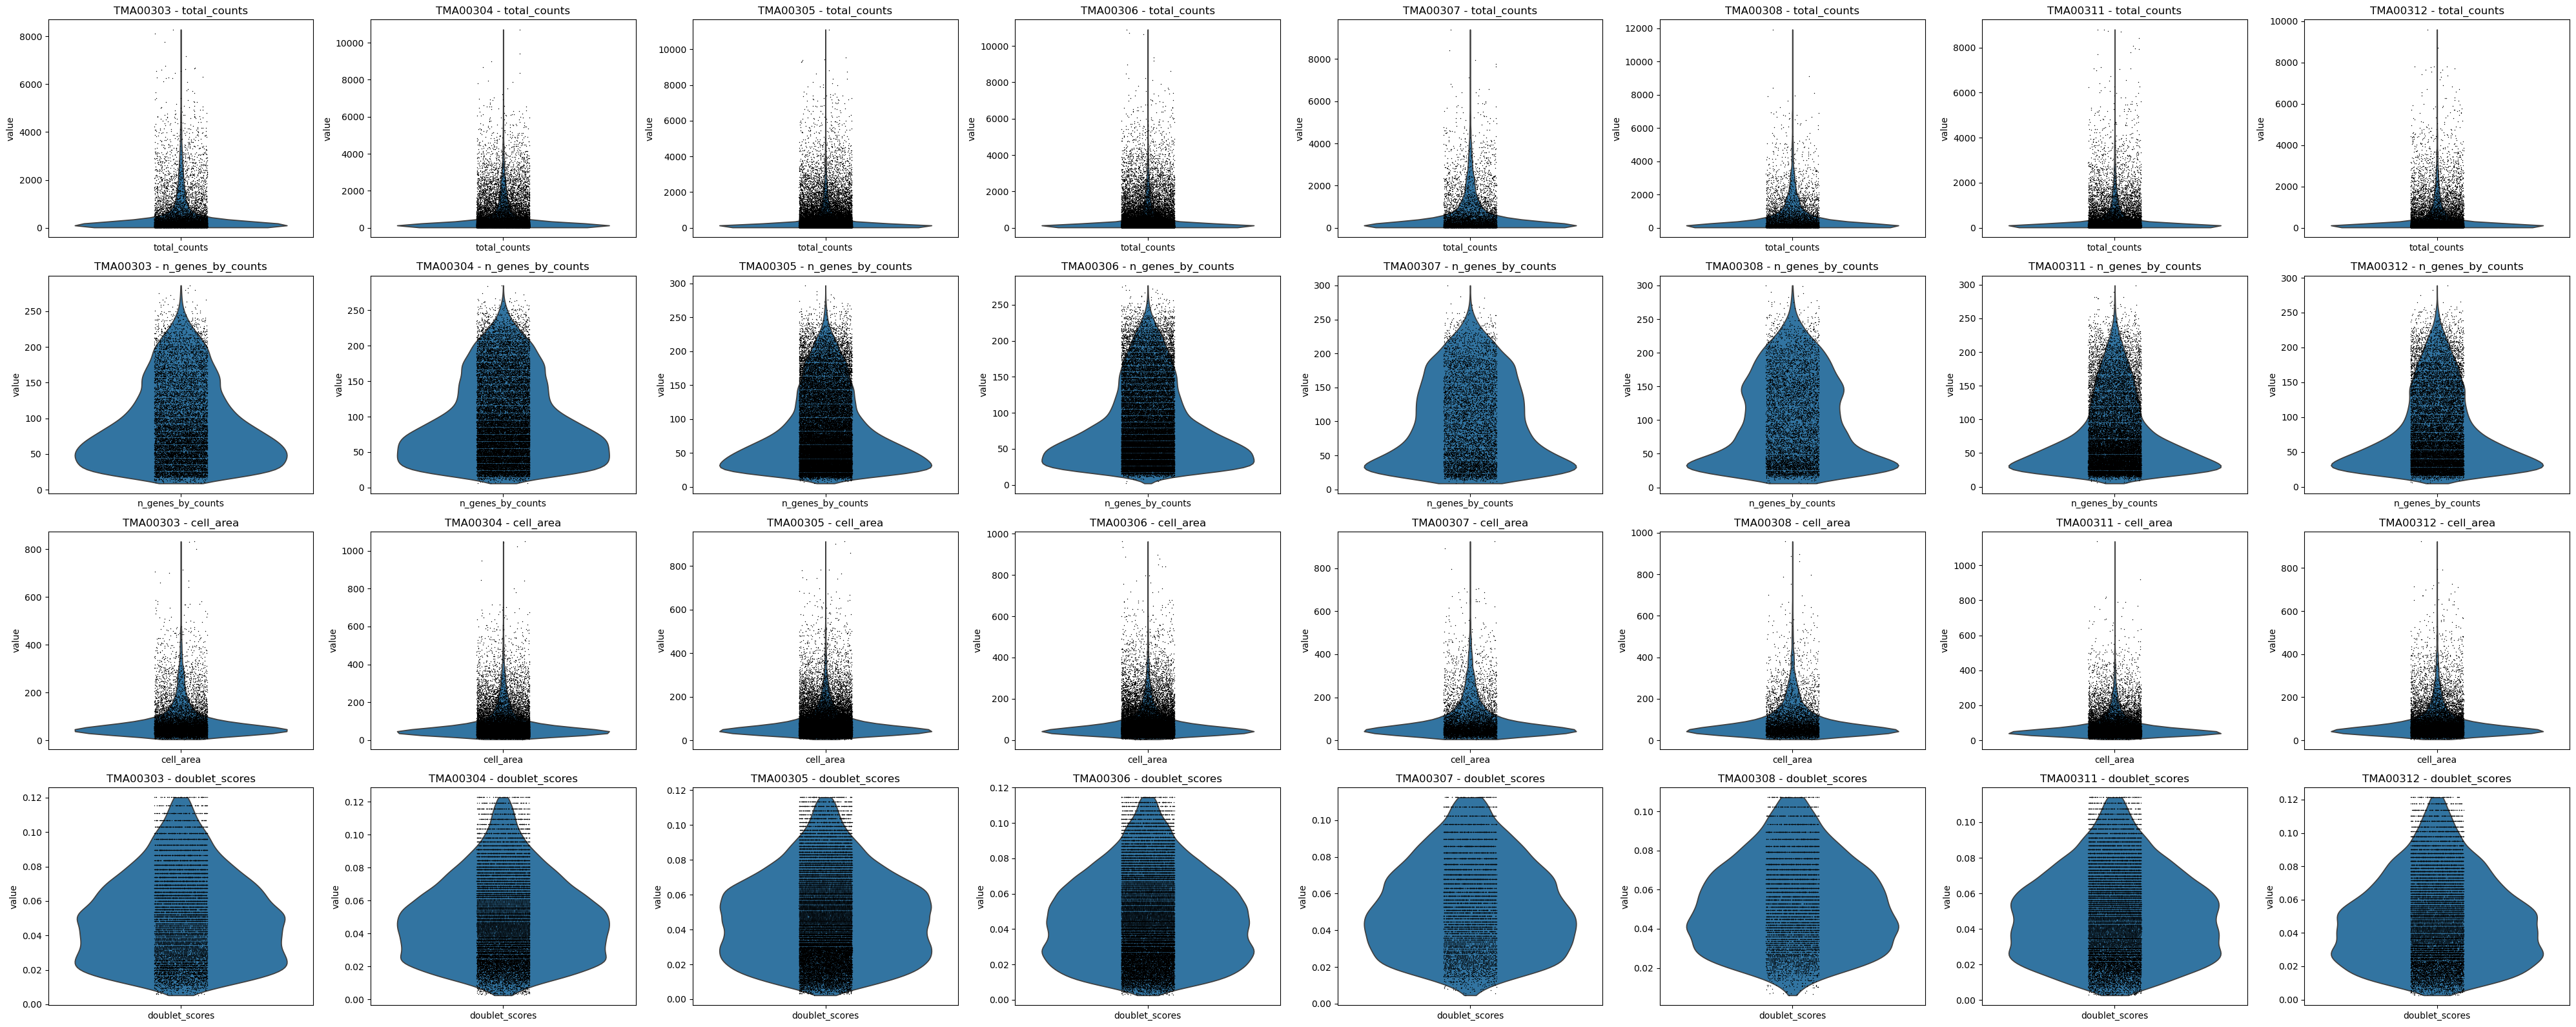

In [9]:
fig, axes = plt.subplots(len(features), len(adata_list), figsize=(len(adata_list) * 5, len(features) * 4))
for col_idx, adata in enumerate(adata_list):
    for row_idx, feature in enumerate(features):
        sc.pl.violin(adata, feature, ax=axes[row_idx, col_idx], show=False)
        axes[row_idx, col_idx].set_title(f"{adata.obs['sample_id'].unique()[0]} - {feature}")

plt.tight_layout()
plt.show()

## Concatenate

In [10]:
adata = ad.concat(adata_list, 
                  join="outer", 
                  label = 'batch', # suffix of adata.obs_names should match batch
                  index_unique="-")

In [11]:
adata

AnnData object with n_obs × n_vars = 146276 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch'
    obsm: 'spatial'

In [12]:
adata.obs.sample_id.value_counts()

sample_id
TMA00305    32361
TMA00306    31535
TMA00304    21020
TMA00311    19336
TMA00312    17302
TMA00303    11122
TMA00307     6835
TMA00308     6765
Name: count, dtype: int64

## Normalization
Only perform library size normalization on branch of data which has the transgenes removed to avoid bias introduced by exogenous transcripts

In [13]:
adata.layers["counts"] = adata.X.copy()

In [14]:
# remove transgenes

def remove_transgenes(adata, pattern="Seq"):
    print(f"\nProcessing: {getattr(adata, 'uns', {}).get('name', 'AnnData')}")
    print(f"Initial # genes: {adata.n_vars}")
    
    transgenes = adata.var_names[adata.var_names.str.contains(pattern, case=False, na=False)]
    print(f"Found {len(transgenes)} transgenes: {list(transgenes)[:10]}{' ...' if len(transgenes) > 10 else ''}")

    adata_filtered = adata[:, ~adata.var_names.isin(transgenes)].copy()
    print(f"Remaining genes: {adata_filtered.n_vars}")

    return adata_filtered
    
adata_subset = remove_transgenes(adata, pattern="Seq")


Processing: AnnData
Initial # genes: 480
Found 5 transgenes: ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']
Remaining genes: 475


In [15]:
sc.pp.normalize_total(adata_subset) # updated to use median default 12/2
adata_subset.layers["normalized"] = adata_subset.X.copy()

sc.pp.log1p(adata_subset)
adata_subset.raw = adata_subset.copy() # freeze log1p in raw slot
adata_subset.layers["log1p"] = adata_subset.X.copy()

In [16]:
print(adata.layers)
print(adata_subset.layers)

Layers with keys: counts
Layers with keys: counts, normalized, log1p


## Export

In [17]:
# 480 genes
filename = os.path.join(output_dir, 'adata-480.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok=True)
adata.write_h5ad(filename, compression='gzip')
print(f'Filtered, concatenated AnnData with all genes saved to: {filename}')

# 475 genes
filename = os.path.join(output_dir, 'adata-475.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok=True)
adata_subset.write_h5ad(filename, compression='gzip')
print(f'Filtered, concatenated AnnData without transgenes saved to: {filename}')

Filtered, concatenated AnnData with all genes saved to: /home/workspace/projects/drg/data/h5ad/export_01/01d_filter/adata-480.h5ad
Filtered, concatenated AnnData without transgenes saved to: /home/workspace/projects/drg/data/h5ad/export_01/01d_filter/adata-475.h5ad


## Session info

In [18]:
print('active IDE: sc-spatial')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial
active conda environment: sc-spatial
